# 项目：用线性回归预测房价数据

## 分析目标

此数据分析报告的目的是，基于已有的房屋销售价格，以及有关该房屋的属性，进行线性回归分析，从而利用得到的线性回归模型，能对以下未知售价的房屋根据属性进行价格预测：

面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

## 简介

数据集`house_price.csv`记录了超过五百栋房屋的交易价格，以及房屋的相关属性信息，包括房屋面积、卧室数、厕所数、楼层数、是否位于主路、是否有客房，等等。

`house_price.csv`每列的含义如下：
- price：房屋出售价格
- area：房屋面积，以平方英尺为单位
- bedrooms：卧室数
- bathrooms：厕所数
- stories：楼层数
- mainroad：是否位于主路
   - yes  是
   - no	  否
- guestroom：是否有客房
   - yes  是
   - no	  否
- basement：是否有地下室
   - yes  是
   - no	  否
- hotwaterheating：是否有热水器
   - yes  是
   - no	  否
- airconditioning：是否有空调
   - yes  是
   - no	  否
- parking：车库容量，以车辆数量为单位
- prefarea：是否位于城市首选社区
   - yes  是
   - no	  否
- furnishingstatus：装修状态
   - furnished       精装
   - semi-furnished	 简装
   - unfurnished     毛坯

## 读取数据

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

我们创建一个DataFrame变量，命名为original_data，用来存储原始数据house_price.csv。

In [2]:
original_data = pd.read_csv('house_price.csv')
original_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 数据评估和清洗

为了将清洗过的数据和原始数据区分，我们创建一个DataFrame变量，取名为cleaned_data，并将original_data复制的副本赋值给cleaned_data，后续所有的清洗操作将在cleaned_data上执行。

In [3]:
cleaned_data = original_data.copy()
cleaned_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


数据评估主要分为两个方面：数据结构和数据内容，即整洁度和干净度。评估数据结构（整洁度）主要评估数据是否符合“每列是一个变量，每行是一个观察值，每个单元格只有一个数据”的整洁数据特点。评估数据内容（干净度）主要评估数据是否存在空缺数据、重复数据、不一致数据、无效和错误数据。

### 数据整洁度

根据cleaned_data的输出结果，数据结构符合整洁数据“每列是一个变量，每行是一个观察值，每个单元格只有一个数据”的特点，数据结构无问题。

### 数据干净度

#### 处理空缺数据

先调用info方法对cleaned_data的整体有个大概了解。

In [4]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


由输出结果可知，cleaned_data一共有545行观察值。由于每一列的非空值数量都是545，所以不存在空缺数据。

#### 处理重复数据

有cleaned_data各变量的含义可知，每一列都可以存在重复数据。

#### 处理不一致数据

不一致数据是指每一列是否存在不一样的值指代同一目标的情况。由original_data各列含义可知，变量furnishingstatus有可能存在不一致数据，而mainroad、guestroom、basement、hotwaterheating、airconditioning、prefarea这些列也需要检查是否包含除了yes和no以外的其他数据，因此调用value_counts检查这些列存所包含的值的种类。

In [5]:
cleaned_data['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [6]:
cleaned_data['guestroom'].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [7]:
cleaned_data['basement'].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [8]:
cleaned_data['hotwaterheating'].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [9]:
cleaned_data['airconditioning'].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [10]:
cleaned_data['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [11]:
cleaned_data['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

由以上输出可以看出，furnishingstatus变量不存在不一致数据，而其他列如mainroad、guestroom、basement、hotwaterheating、airconditioning、prefarea包含的数据除了yes和no以外，没有其他数据。另外这些列包含的值只有2种或者3种，因此可以将它们的数据类型转换成Category，一方面可以节省内存空间，另一方面也方便后续线性回归分析时为数据引入虚拟变量。

In [12]:
cleaned_data['mainroad'] = cleaned_data['mainroad'].astype('category')

In [13]:
cleaned_data['guestroom'] = cleaned_data['guestroom'].astype('category')

In [14]:
cleaned_data['basement'] = cleaned_data['basement'].astype('category')

In [15]:
cleaned_data['hotwaterheating'] = cleaned_data['hotwaterheating'].astype('category')

In [16]:
cleaned_data['airconditioning'] = cleaned_data['airconditioning'].astype('category')

In [17]:
cleaned_data['prefarea'] = cleaned_data['prefarea'].astype('category')

In [18]:
cleaned_data['furnishingstatus'] = cleaned_data['furnishingstatus'].astype('category')

In [19]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 29.5 KB


#### 处理无效和错误数据

调用describe方法来查看cleaned_data中的数值数据的统计信息。

In [20]:
cleaned_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


从输出结果来看，cleaned_data不存在脱离现实意义的数据。

## 探索数据

在进行线性回归分析之前，我们可以利用数据可视化，对房屋价格和属性数据进行探索，这样有助于为数据分析提供方向。由于分析的目的是通过已知的房屋价格及房屋属性，进行线性回归分析，并根据各属性值预测房屋价格，因此可以用可视化探索房屋属性与房屋价格的关系，也可以探索数据变量分布等。

In [21]:
cleaned_data.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
78,6650000,5700,3,1,1,yes,yes,yes,no,yes,2,yes,furnished
325,4007500,3460,4,1,2,yes,no,no,no,yes,0,no,semi-furnished
265,4403000,2880,3,1,2,yes,no,no,no,no,0,yes,semi-furnished
434,3290000,3792,4,1,2,yes,no,no,no,no,0,no,semi-furnished
95,6300000,4100,3,2,3,yes,no,no,no,yes,2,no,semi-furnished
298,4200000,5800,3,1,1,yes,no,no,yes,no,2,no,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
322,4025000,3460,3,2,1,yes,no,yes,no,yes,1,no,furnished
256,4480000,4000,3,1,2,yes,no,no,no,no,2,no,furnished
332,3920000,5500,4,1,2,yes,yes,yes,no,no,0,no,semi-furnished


### 探索房屋价格的分布情况

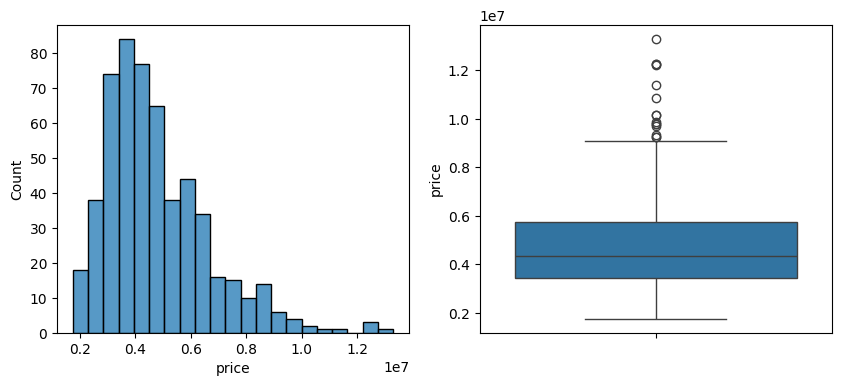

In [22]:
fig,axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(cleaned_data, x="price", ax=axes[0])
sns.boxplot(data = cleaned_data, y="price",ax=axes[1])
plt.show()

从直方图可知，房价呈右偏态分布，大多数房屋价格集中在400万左右，有极少数极端高房价拉高了平均价格。

### 探索房屋面积的分布情况

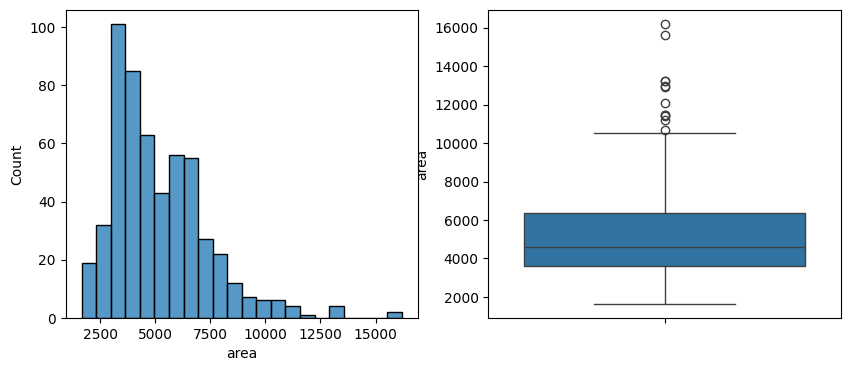

In [23]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(cleaned_data, x="area", ax=axes[0])
sns.boxplot(data=cleaned_data, y="area", ax=axes[1])
plt.show()

房屋面积也呈右态分布，中等面积的居多，个别大面积房屋存在极端值。

### 探索房屋面积和价格的关系

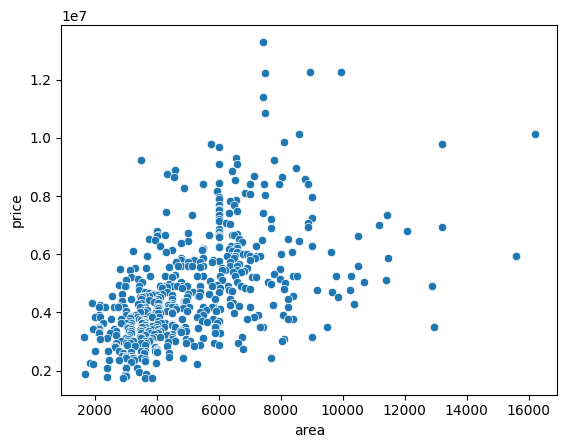

In [24]:
sns.scatterplot(data=cleaned_data, x="area",y="price")
plt.show()

从散点图来看，房屋面积越大，房价越高。

### 探索房屋卧室数量与房屋价格的关系

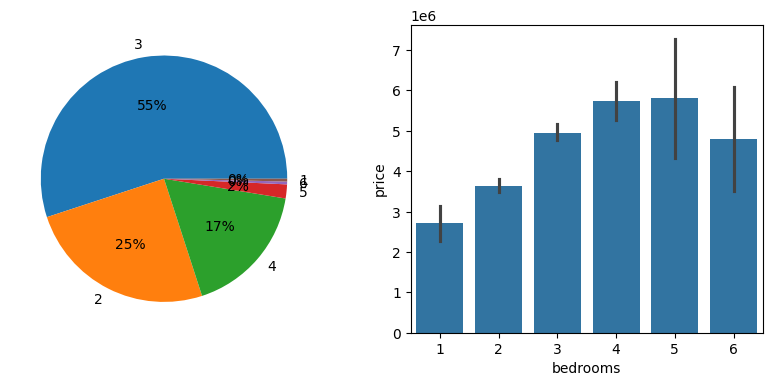

In [25]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
bedrooms_counts = cleaned_data['bedrooms'].value_counts()
axes[0].pie(bedrooms_counts, labels=bedrooms_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="bedrooms", y="price", ax=axes[1])
plt.show()

从饼图来看，卧室数在3个的房屋数量最多，其次是拥有2间卧室和1间卧室的房屋，卧室数量在5个和6个的房屋占比最少。
从条形图来看，卧室数量在5个以内时，卧室越多，房价越高，卧室数量为6时，房价有所下降。

### 探索厕所数量与房屋价格的关系

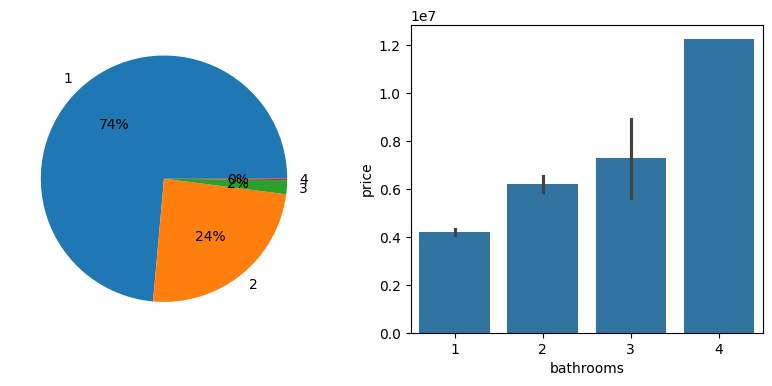

In [26]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
bathrooms_counts = cleaned_data['bathrooms'].value_counts()
axes[0].pie(bathrooms_counts, labels=bathrooms_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="bathrooms", y="price")
plt.show()

由饼图来看，拥有1个厕所的房子数量最多，占比74%，拥有2个厕所的房子数量占比24，拥有3个和4个厕所的房子数量较少。
由条形图来看，厕所数量越多，房价越高。

### 探索楼层数量与房屋价格的关系

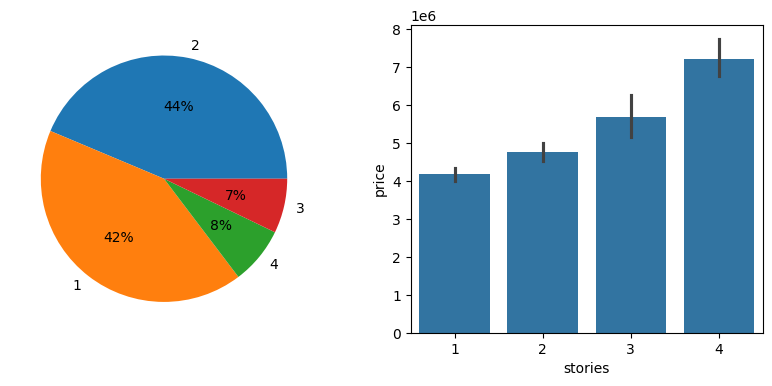

In [27]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
stories_counts = cleaned_data['stories'].value_counts()
axes[0].pie(stories_counts, labels=stories_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="stories", y="price")
plt.show()

由饼图来看，楼层为2层的房子数量最多，占44%%，其次是楼层为1层的房子，占比42%，楼层为3和4层的房子占比较少。
由条形图来看，楼层越高，房价越高。

### 探索是否靠近主路段与房屋价格的关系

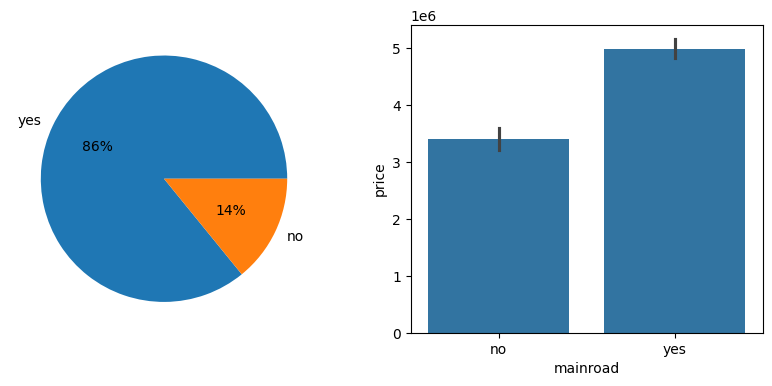

In [28]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
mainroad_counts = cleaned_data['mainroad'].value_counts()
axes[0].pie(mainroad_counts, labels=mainroad_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="mainroad", y="price")
plt.show()

由饼图来看，靠近主路段的房子占大多数，占比86，不靠近主路段的房子占比14%。
由条形图来看，靠近主路段的房价较高。

### 探索是否有客房与房屋价格的关系

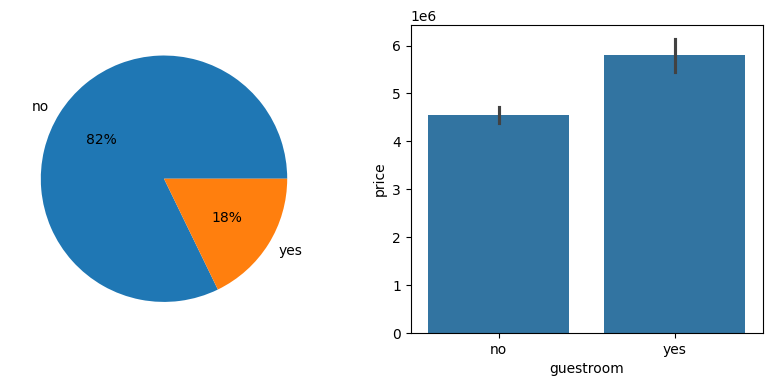

In [29]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
guestroom_counts = cleaned_data['guestroom'].value_counts()
axes[0].pie(guestroom_counts, labels=guestroom_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="guestroom", y="price")
plt.show()

由饼图来看，不带客房的房屋占比居多，占比82，带有客房的房子占比18%。
由条形图来看，有客房的房价比没有客房的房价普遍高一些。

### 探索是否有地下室与房屋价格的关系

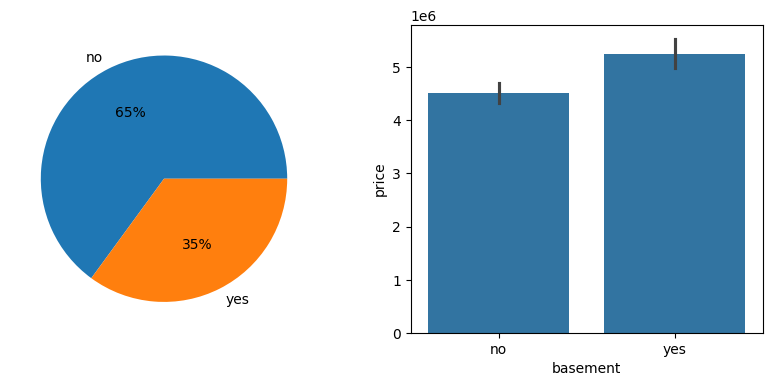

In [30]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
basement_counts = cleaned_data['basement'].value_counts()
axes[0].pie(basement_counts, labels=basement_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="basement", y="price")
plt.show()

由饼图来看，没有地下室的房屋占大多数，占比65%，有地下室的房屋数量占比35%。
由条形图来看，有地下室的房屋价格比没有地下室的要高一些。

### 探索是否安装热水器与房屋价格的关系

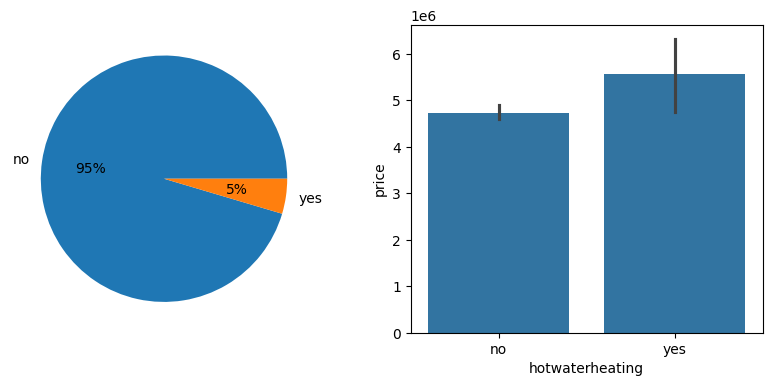

In [31]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
hotwaterheating_counts = cleaned_data['hotwaterheating'].value_counts()
axes[0].pie(hotwaterheating_counts, labels=hotwaterheating_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="hotwaterheating", y="price")
plt.show()

由饼图来看，没有安装热水器的房屋数量占大多数，占比95。
由条形图来看，安装热水器的房屋价格比没有安装热水器房屋价格的要高一些。

### 探索是否安装空调与房屋价格的关系

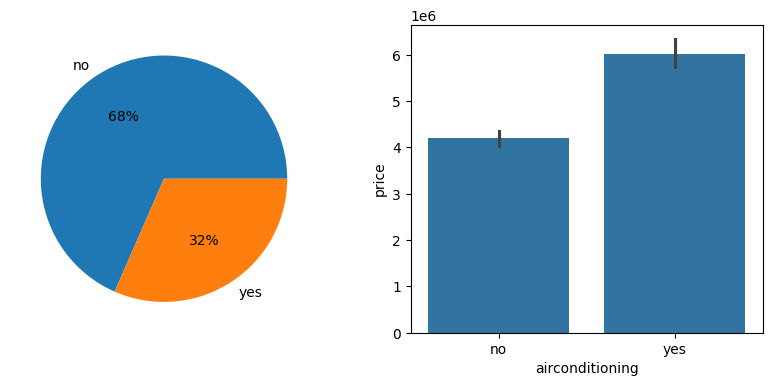

In [32]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
airconditioning_counts = cleaned_data['airconditioning'].value_counts()
axes[0].pie(airconditioning_counts, labels=airconditioning_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="airconditioning", y="price")
plt.show()

由饼图来看，没有安装空调的房屋数量占大多数，占比68%，安装空调的房子数量占比32%。
由条形图来看，安装空调的房屋价格比没有安装空调房屋价格的要高一些。

### 探索车库停车位数量与房屋价格的关系

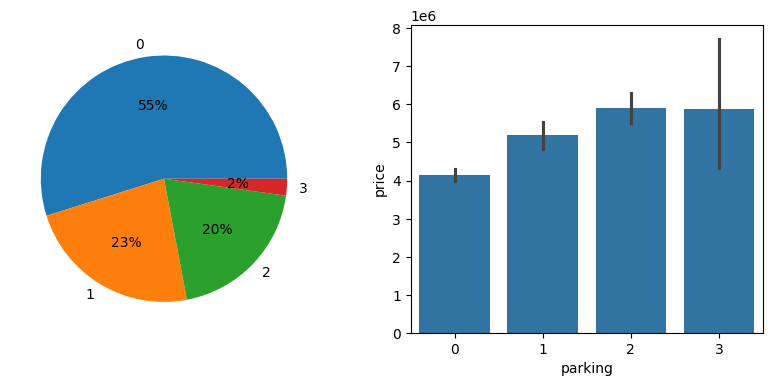

In [33]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
parking_counts = cleaned_data['parking'].value_counts()
axes[0].pie(parking_counts, labels=parking_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="parking", y="price")
plt.show()

由饼图来看，没有车库停车位的房屋数量较多，占比55%，有1个和2个停车位的房屋数量其次，占比23%和20%，有3个停车位的房屋数量较少，占比3%。
由条形图来看，停车为数量在2以内，停车位越多，房屋价格越高，停车位为3个时，与2个停车位房价基本持平。

### 探索是否为位于城市首选社区与房屋价格的关系

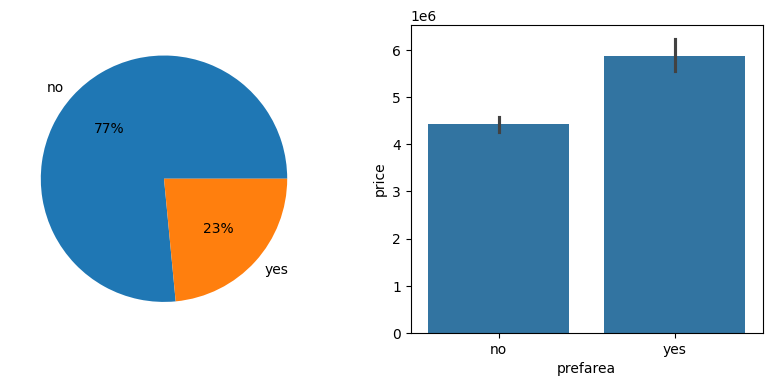

In [34]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
prefarea_counts = cleaned_data['prefarea'].value_counts()
axes[0].pie(prefarea_counts, labels=prefarea_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="prefarea", y="price")
plt.show()

由饼图来看，没有位于首选社区的房屋数量较多，占比77%，位于首选社区的房屋数量占比23%。
由条形图来看，位于首选社区的房价相对较高。

### 探索装修状态与房屋价格的关系

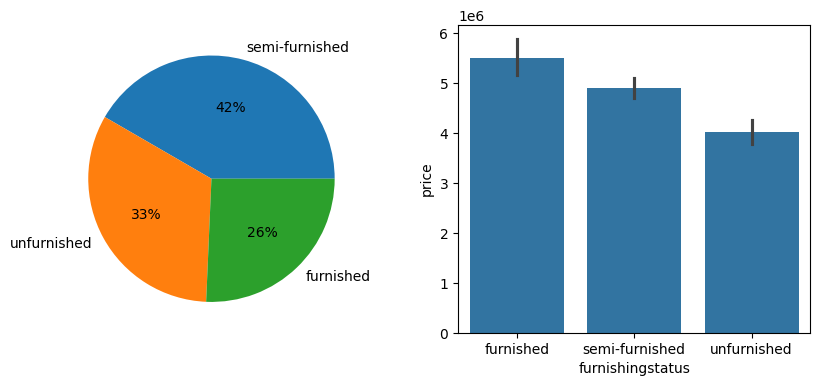

In [35]:
fig, axes=plt.subplots(1,2, figsize=(10,4))
furnishingstatus_counts = cleaned_data['furnishingstatus'].value_counts()
axes[0].pie(furnishingstatus_counts, labels=furnishingstatus_counts.index, autopct="%.0f%%")
sns.barplot(data=cleaned_data, x="furnishingstatus", y="price")
plt.show()

由饼图来看，简装修的房屋数量较多，占比42%，毛坯房数量其次，占比33%，精装修房屋数量较少，占比26%。
由条形图来看，精装修的房价最高，简装修房价中等，毛坯房的房价较低。

## 数据分析

本次分析的目的是基于已有的房屋出售价格和房屋属性进行线性回归分析，利用得到的线性回归模型预测房价。在进行线性回归分析前，我们创建一个新的DataFrame变量，取名为ir_data，并将cleaned_data复制的副本赋值给ir_data，因为我们在线性回归分析之前，还需要进行一些准备工作，比如引入虚拟变量，lr_data就用来执行后续这些线性回归分析相关的操作。

In [36]:
lr_data = cleaned_data.copy()
lr_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### 创建虚拟变量

mainroad、guestroom、basement、hotwaterheating、airconditioning、prefarea、furnishingstatus这些都属于分类变量，因此需要引入虚拟变量替代这些分类变量，并用0和1表示是否属于该分类。

In [37]:
lr_data = pd.get_dummies(lr_data, columns=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'], 
                      dtype=int, drop_first=True)
lr_data.sample(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
77,6650000,6500,3,2,3,0,1,0,0,0,1,1,0,0
491,2835000,2640,2,1,1,1,0,0,0,0,0,0,0,0
15,9100000,6000,4,1,2,2,1,0,1,0,0,0,1,0
99,6265000,6000,4,1,3,0,1,1,1,0,0,1,0,1
107,6125000,6420,3,1,3,0,1,0,1,0,0,1,0,1
6,10150000,8580,4,3,4,2,1,0,0,0,1,1,1,0
35,8080940,7000,3,2,4,2,1,0,0,0,1,0,0,0
309,4130000,4632,4,1,2,0,1,0,0,0,1,0,1,0
341,3850000,3180,2,2,1,2,1,0,1,0,0,0,1,0
317,4060000,4992,3,2,2,2,1,0,0,0,0,0,0,1


### 创建线性回归模型的自变量y和因变量X

由于分析的目的是根据已有房价和房屋属性进行线性回归分析，并且根据得到的线性回归模型预测房价，因此需要将房屋价格price列纳入因变量，而其他关于房屋属性的所有列则可以暂时先纳入自变量，后续再检查所有房屋属性变量之间是否存在共线性。

In [38]:
y = lr_data['price']

In [39]:
X = lr_data.drop(['price'], axis=1)
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


接下来需要检查X所有变量之间的相关系数，因为相关系数过高会导致共线性问题，一般情况下认为相关系数绝对值大于0.8则会出现共线性问题，因此需要找出相关系数绝对值大于0.8的值。

In [40]:
X.corr().abs() > 0.8

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
area,True,False,False,False,False,False,False,False,False,False,False,False,False
bedrooms,False,True,False,False,False,False,False,False,False,False,False,False,False
bathrooms,False,False,True,False,False,False,False,False,False,False,False,False,False
stories,False,False,False,True,False,False,False,False,False,False,False,False,False
parking,False,False,False,False,True,False,False,False,False,False,False,False,False
mainroad_yes,False,False,False,False,False,True,False,False,False,False,False,False,False
guestroom_yes,False,False,False,False,False,False,True,False,False,False,False,False,False
basement_yes,False,False,False,False,False,False,False,True,False,False,False,False,False
hotwaterheating_yes,False,False,False,False,False,False,False,False,True,False,False,False,False
airconditioning_yes,False,False,False,False,False,False,False,False,False,True,False,False,False


由输出结果来看，没有找到各个房屋属性变量之间相关性大于0.8的值，因此不存在共线性问题。

### 给线性回归方程模型加入截距

为了得到完整的线性回归模型，还需要对已有的自变量X增加一列常量作为线性回归方程的截距。

In [41]:
X = sm.add_constant(X)
X.head()

,const,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,1.0,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,1.0,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,1.0,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,1.0,7420,4,1,2,2,1,1,1,0,1,0,0,0


### 建立线性回归模型并对数据进行拟合

建立线性回归模型。

In [42]:
model = sm.OLS(y, X)

对数据进行拟合。

In [43]:
result = model.fit()

对拟合结果进行汇总展示

In [44]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Sat, 23 May 2026   Prob (F-statistic):          9.07e-123
Time:                        11:40:21   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
mainroad_yes                     4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom_yes                    3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement_yes                     3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating_yes              8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning_yes               8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
prefarea_yes                     6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

根据输出结果，变量const、bedrooms和furnishingstatus_semi-furnished的P值大于显著水平0.05，因此被认为对因变量y的值没有显著影响，因此需要在X中去掉这三列重新拟合。

In [45]:
X = X.drop(['const','bedrooms','furnishingstatus_semi-furnished'],axis=1)
X.head()

,area,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_unfurnished
0,7420,2,3,2,1,0,0,0,1,1,0
1,8960,4,4,3,1,0,0,0,1,0,0
2,9960,2,2,2,1,0,1,0,0,1,0
3,7500,2,2,3,1,0,1,0,1,1,0
4,7420,1,2,2,1,1,1,0,1,0,0


重新建立模型并拟合。

In [46]:
model = sm.OLS(y, X)
result = model.fit()

对拟合结果进行汇总展示。

In [47]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Sat, 23 May 2026   Prob (F-statistic):                        0.00
Time:                        11:40:21   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           257.5854     22.577     11.409      0.000     213.234     301.936
bathrooms                     1.071e+06   9.27e+04     11.553      0.000    8.89e+05    1.25e+06
stories                       5.084e+05   5.71e+04      8.898      0.000    3.96e+05    6.21e+05
parking                       2.793e+05   5.83e+04      4.794      0.000    1.65e+05    3.94e+05
mainroad_yes                  4.672e+05   1.27e+05      3.679      0.000    2.18e+05    7.17e+05
guestroom_yes                 2.851e+05   1.31e+05      2.172      0.030    2.72e+04    5.43e+05
basement_yes                  4.016e+05   1.07e+05      3.765      0.000    1.92e+05    6.11e+05
hotwaterheating_yes           8.668e+05   2.23e+05      3.884      0.000    4.28e+05    1.31e+06
airconditioning_yes           8.543e+05   1.07e+05      7.952      0.000    6.43e+05    1.07e+06
prefarea_yes                  6.443e+05   1.15e+05      5.594      0.000    4.18e+05    8.71e+05
furnishingstatus_unfurnished -3.493e+05   9.49e+04     -3.679      0.000   -5.36e+05   -1.63e+05
==============================================================================
Omnibus:                       94.840   Durbin-Watson:                   1.262
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              251.889
Skew:                           0.865   Prob(JB):                     2.01e-55
Kurtosis:                       5.845   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

可以看到，对线性回归模型重新调整拟合后，R方的值从0.682升至0.957，说明模型对数据的拟合程度提高了。

也可以从线性回归方程各自变量系数看出：area（面积）、bathrooms（卧室数量）、stories（楼层数量）、parking（车库停车位数量）、mainroad_yes（靠近主路段）、guestroom_yes（有客房）、basement_yes（有地下室）、hotwaterheating_yes（安装热水器）、airconditioning_yes（安装空调）、prefarea_yes（位于城市首选社区）这些因素增加或存在会提升房屋价格，而furnishingstatus_unfurnished（装修情况为毛坯房）的存在会降低房屋价格。

### 预测房屋价格

根据本次分析的目的，需要利用得到的线性回归模型根据以下房屋属性预测房屋价格：  
面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

我们可以创建一个新的DataFrame变量，取名为new_data，用来储存需要预测房屋价格的房子的房屋属性。

In [48]:
new_data = pd.DataFrame({'area':[6500], 'bedrooms':[4], 'bathrooms':[2] ,'stories':[2], 'mainroad':['no'], 'guestroom':['no'], 'basement':['yes'], 
                         'hotwaterheating':['yes'], 'airconditioning':['no'], 'parking':[2], 'prefareas':['yes'], 'furnishingstatus':['semi-furnished']})
new_data

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefareas,furnishingstatus
0,6500,4,2,2,no,no,yes,yes,no,2,yes,semi-furnished


由于数据new_data的分类变量包含的值种类可能不全，所有需要将分类变量的类型转化为Category，并设置categories参数为包含所有分类变量值的列表，让程序知道所有的分类值，以便在给new_data引入虚拟变量的时候不会漏掉其他分类。

In [49]:
new_data['mainroad'] = pd.Categorical(new_data['mainroad'], categories=['no', 'yes'])
new_data['guestroom'] = pd.Categorical(new_data['guestroom'], categories=['no', 'yes'])
new_data['basement'] = pd.Categorical(new_data['basement'], categories=['no', 'yes'])
new_data['hotwaterheating'] = pd.Categorical(new_data['hotwaterheating'], categories=['no', 'yes'])
new_data['airconditioning'] = pd.Categorical(new_data['airconditioning'], categories=['no', 'yes'])
new_data['prefareas'] = pd.Categorical(new_data['prefareas'], categories=['no', 'yes'])
new_data['furnishingstatus'] = pd.Categorical(new_data['furnishingstatus'], categories=['furnished', 'semi-furnished', 'unfurnished'])

接下来为new_data引入虚拟变量代替分类变量，并用0和1表示是否属于这个分类。

In [50]:
new_data = pd.get_dummies(new_data, columns=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefareas','furnishingstatus'], dtype=int,
                         drop_first=True)
new_data

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefareas_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6500,4,2,2,2,0,0,1,1,0,1,1,0


由于需要预测的数据中因变量的名字必须与线性回归模型方程的因变量相吻合，因此需要删除bedrooms、furnishingstatus_semi-furnished这两列。

In [51]:
new_data = new_data.drop(['bedrooms','furnishingstatus_semi-furnished'], axis=1)
new_data.head()

,area,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefareas_yes,furnishingstatus_unfurnished
0,6500,2,2,2,0,0,1,1,0,1,0


将new_data代入线性回归模型，调用predict方法得出预测结果。

In [52]:
result.predict(new_data)

0    7.303754e+06
dtype: float64

## 结论

利用线性回归模型，预测的房屋价格为：7303754